<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt


iris = load_iris()
X = iris.data
y = iris.target

# Define a range of k values to test
k_range = range(1, 31)
k_scores = []

# Perform cross-validation for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

# Find the optimal k
optimal_k_index = np.argmax(k_scores);
optimal_k = k_range[optimal_k_index]

print(f"Average cross-validation scores for different k values: {k_scores}")
print(f"The optimal k value is: {optimal_k} with an average accuracy of {k_scores[optimal_k_index]:.4f}")

Average cross-validation scores for different k values: [np.float64(0.96), np.float64(0.9533333333333334), np.float64(0.9666666666666666), np.float64(0.9666666666666666), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9733333333333334), np.float64(0.9666666666666668), np.float64(0.9666666666666668), np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9733333333333334), np.float64(0.9800000000000001), np.float64(0.9666666666666666), np.float64(0.9666666666666666), np.float64(0.9733333333333334), np.float64(0.96), np.float64(0.9666666666666666), np.float64(0.96), np.float64(0.9666666666666666), np.float64(0.9533333333333334), np.float64(0.9533333333333334), np.float64(0.9533333333333334)]
The optimal k value is: 1

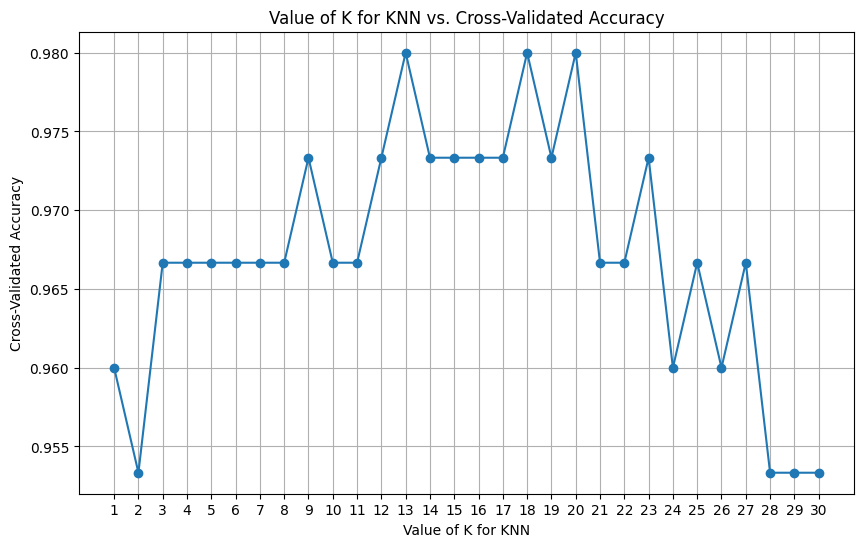

In [3]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Value of K for KNN vs. Cross-Validated Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

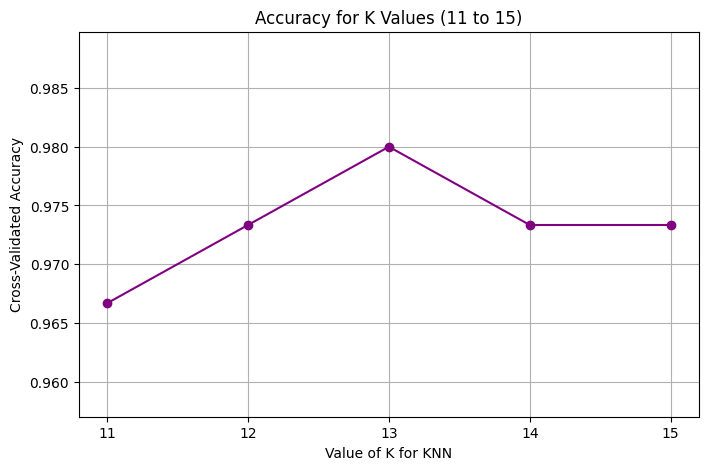

In [8]:
import matplotlib.pyplot as plt

# Define the specific k values from 11 to 15
k_subset = range(11, 16) # k from 11 to 15 inclusive

# Extract corresponding accuracy scores from k_scores
accuracy_subset = [k_scores[k - 1] for k in k_subset]

# Plot these specific k values and accuracies
plt.figure(figsize=(8, 5))
plt.plot(k_subset, accuracy_subset, marker='o', linestyle='-', color='purple')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Accuracy for K Values (11 to 15)')
plt.xticks(k_subset)
plt.grid(True)
plt.ylim(min(accuracy_subset) * 0.99, max(accuracy_subset) * 1.01) # Adjust y-axis limit for better visualization
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': k_range}

# Create a KNeighborsClassifier instance
knn_grid = KNeighborsClassifier()

# Create GridSearchCV object
grid_search = GridSearchCV(knn_grid, param_grid, cv=10, scoring='accuracy')

# Fit GridSearchCV to the data
grid_search.fit(X, y)

# Print the best parameters and best score
print(f"Best parameters found by GridSearchCV: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Best parameters found by GridSearchCV: {'n_neighbors': 13}
Best cross-validation accuracy: 0.9800


The plot above visualizes how the average cross-validation accuracy changes with different `k` values. The optimal `k` corresponds to the peak of this curve.